# Лабораторная работа №1: Основы интерпретируемости моделей

## Задание 1: Ловушка «Золотого признака»

Задача — построить модель, оценивающую «справедливую» зарплату для кандидатов на основе их опыта и навыков.


In [1]:
!pip install interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.1/780.1 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.9/264.9 kB 22.1 MB/s eta 0:00:00
  Created wheel for dash-cytoscape: filename=dash_cytoscape-1.0.2-py3-none-any.whl size=

In [2]:
# Используемые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingRegressor
from interpret import show

In [3]:
df = pd.read_csv("Task_1.csv")
df.head()

,Experience_Years,Python_Score,Coffee_ID,Salary
0,11.236204,5.355402,11.236212,82630.748330
1,28.521429,2.329311,28.521423,99865.428396
2,21.959818,5.760396,21.959806,95425.868067
3,17.959755,6.221171,17.959744,96587.654414
4,4.680559,6.119581,4.680554,71025.454020


**Линейный baseline.** Обучение `LinearRegression` на признаках `Experience_Years`, `Python_Score` и `Coffee_ID`.

In [4]:
X = df[["Experience_Years", "Python_Score", "Coffee_ID"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

# R^2
r2 = r2_score(y_test, y_pred)
print("R^2:", r2)

R^2: 0.8463491823700955


Модель объясняет примерно 85% разброса зарплат, значение близко к 1, модель кажется очень точной.

Визуализация коэффициентов:

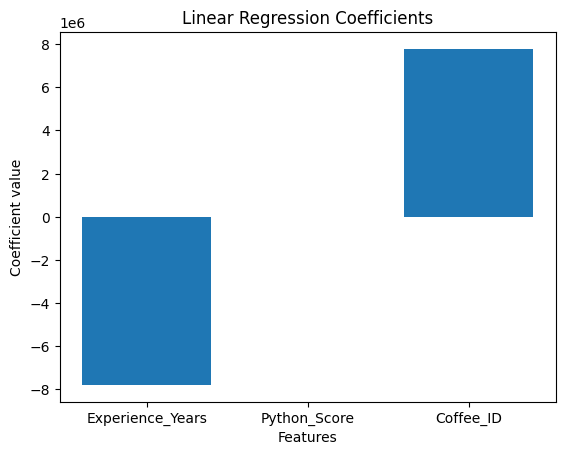

Коэффициенты: [-7.78594296e+06  1.07260689e+03  7.78760401e+06]


In [5]:
coefficients = lin_reg.coef_
features = X.columns

plt.figure()
plt.bar(features, coefficients)
plt.title("Linear Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient value")
plt.show()

print("Коэффициенты:", coefficients)

Коэффициенты для Experience_Years и Coffee_ID имеют огромные, примерно одинаковые значения и противоположные знаки. Они ведут себя так, потому что Coffee_ID практически совпадает с Experience_Years, из-за этого признаки сильно коррелируют и возникает мультиколлинеарность. Модель искусственно разложила нормальный коэффициент на два огромных противоположных, которые нельзя интерпретировать. Данные коэффициенты нельзя использовать для объяснения логики зарплат.


**Нелинейный аудит.** Уберем признак `Coffee_ID` и сравним работу `LinearRegression` и `ExplainableBoostingRegressor`.

In [6]:
X2 = df[["Experience_Years", "Python_Score"]]

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

# LinearRegression
lin_model = LinearRegression()
lin_model.fit(X2_train, y_train)
y_pred_lin = lin_model.predict(X2_test)

r2_lin = r2_score(y_test, y_pred_lin)
print("Linear Regression R^2:", r2_lin)

# ExplainableBoostingRegressor
ebm_model = ExplainableBoostingRegressor()
ebm_model.fit(X2_train, y_train)
y_pred_ebm = ebm_model.predict(X2_test)

r2_ebm = r2_score(y_test, y_pred_ebm)
print("EBM R^2:", r2_ebm)

Linear Regression R^2: 0.8462564573952663
EBM R^2: 0.9865602215836091


LinearRegression показала R² чуть меньше, чем с Coffee_ID, но коэффициенты теперь отражают реальное влияние опыта и навыков на зарплату. Линейная модель предполагает прямую зависимость зарплаты от опыта.

EBM показывает почти идеальное предсказание. Модель не ограничена линейностью, строит гибкую кривую зависимости, поэтому точность выше, чем у линейной регрессии.

Построим графики зависимости зарплаты от опыта.

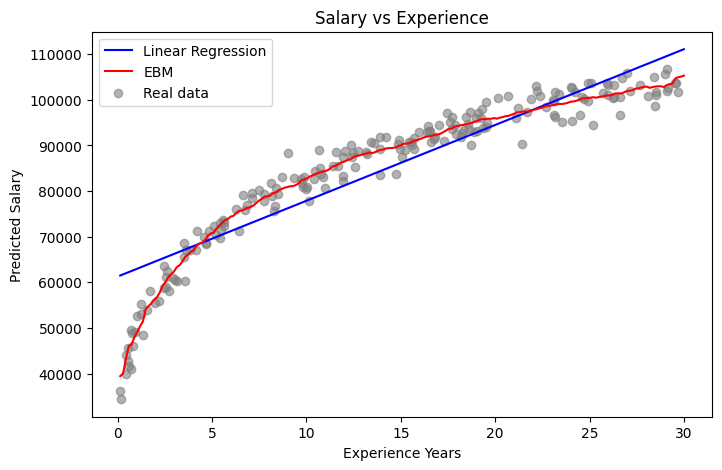

In [7]:
# Сетка значений опыта
experience_range = np.linspace(
    df["Experience_Years"].min(),
    df["Experience_Years"].max(),
    200
)

mean_python = df["Python_Score"].mean()

X_plot = pd.DataFrame({
    "Experience_Years": experience_range,
    "Python_Score": mean_python
})

y_lin_plot = lin_model.predict(X_plot)
y_ebm_plot = ebm_model.predict(X_plot)

plt.figure(figsize=(8,5))
plt.plot(experience_range, y_lin_plot, label="Linear Regression", color="blue")
plt.plot(experience_range, y_ebm_plot, label="EBM", color="red")
plt.scatter(X2_test["Experience_Years"], y_test, label="Real data", color="gray", alpha=0.6)
plt.xlabel("Experience Years")
plt.ylabel("Predicted Salary")
plt.title("Salary vs Experience")
plt.legend()
plt.show()

График предсказаний показывает:

- **Linear Regression** строит прямую линию, предполагая равный прирост зарплаты с каждым годом опыта.  
- **EBM** строит гибкую кривую, которая более точно проходит через реальные точки. На графике заметна **«точка перелома»** примерно на 5 годах опыта: до нее зарплата растёт быстро, после прирост немного замедляется.  

**Вывод:** EBM лучше описывает реальную зависимость и правильно отражает замедление роста. Linear Regression делает грубое приближение, считает, что прирост зарплаты постоянен, не учитывает перегиб кривой и поэтому на участках с малым или большим опытом недооценивает или переоценивает реальные значения.

## Задание 2: Финтех-детектив (The Hidden Pattern)

Задача — обучить самую точную, но при этом безопасную и интерпретируемую модель для оценки дохода на «грязном» датасете.


In [8]:
df2 = pd.read_csv("Task_2.csv")
df2.head()

,User_ID,Age,Gender,City,Education,Marital_Status,Shoe_Size,Height,Zodiac,Color,Pets,Salary
0,45,40,M,Tokyo,PhD,Divorced,41.049559,173.669434,Leo,Blue,2,112341.922612
1,668,35,M,London,Master,Divorced,38.332265,176.865556,Sagittarius,Green,4,93439.035481
2,1650,52,M,NY,School,Married,39.000203,168.978529,Scorpio,Green,0,100613.339512
3,1247,54,M,Tokyo,School,Married,37.376580,170.917175,Scorpio,Green,3,121936.362834
4,18,59,F,NY,PhD,Single,39.269697,164.641542,Sagittarius,Blue,4,141688.826664


**Слепое обучение.** Обучим модель `EBM` на всех доступных признаках, чтобы получить максимально возможную точность.

In [9]:
X2 = df2.drop(columns=["Salary"])
y2 = df2["Salary"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

ebm2 = ExplainableBoostingRegressor()
ebm2.fit(X2_train, y2_train)
y2_pred = ebm2.predict(X2_test)

r2_ebm2 = r2_score(y2_test, y2_pred)
print("EBM R^2:", r2_ebm2)

EBM R^2: 0.9414281967811668


Модель объясняет около 94% разброса зарплаты на тестовой выборке, предсказания кажутся очень точными.

 **Глобальный аудит.** Используем метод `ebm.explain_global()`, который создаёт глобальное объяснение модели, для анализа важности признаков. Посмотрим, как изменение признака влияет на предсказание.

In [10]:
ebm_global = ebm2.explain_global()

feature_importance = pd.DataFrame({
    "Feature": ebm_global.data()["names"],
    "Importance": ebm_global.data()["scores"]
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,User_ID,13005.556288
1,Age,10177.595737
3,City,9404.249669
4,Education,7533.450600
6,Shoe_Size,719.153308
...,...,...
58,Shoe_Size & Color,13.878323
29,Age & Pets,12.903467
12,User_ID & Gender,9.207936
32,Gender & Marital_Status,8.520313


Если посмотреть на топ-5 самых важных признаков по мнению модели, то Age, City и Education логично влияют на доход. User_ID это идентификатор клиента, который вряд-ли имеет связь с доходом. Высокая важность говорит о том, что модель «случайно» использовала корреляции из обучающих данных. Shoe_Size тоже выглядит странно и не имеет очевидной связи с доходом, возможно, случайная корреляция в данных.

**Визуальный анализ.** Для признаков из топ-5 построим графики их вклада.

In [11]:
top5 = feature_importance["Feature"].head(5).tolist()

for feature in top5:
    print(f"Feature: {feature}")
    show(ebm_global, feature)


Output hidden; open in https://colab.research.google.com to view.

По графикам видно, что признак User_ID выглядит аномально, имеет периодическую синусоидальную форму по всему диапазону значений, что не имеет логического объяснения. Модель обнаружила случайную корреляцию между номером клиента и зарплатой. Возможно, данные были отсортированы по зарплате или компании/отделу, из-за чего номер начал косвенно влиять на зарплату. Или из-за высокой гибкости модель может увидеть случайные локальные колебания, начать под них подстраиваться и нарисовать "волну". EBM строит вклад признака как сумму слабых деревьев. Вероятно, когда бустинг пытается повысить вклад в одном диапазоне, понизить в другом, снова повысить, получается волнообразная форма.

Если оставить этот признак в продакшене, при появлении новых клиентов с новыми ID предсказания станут некорректными, что приведёт к ухудшению качества модели. Следовательно, признак User_ID необходимо удалить и переобучить модель.

У признака Shoe_Size важность не такая большая, кривая графика близка к 0 с небольшими колебаниями. Это уже менее критично, признак не сильно влияет.


In [12]:
X2_fixed = df2.drop(columns=["Salary", "User_ID"])
y2 = df2["Salary"]

X2_train_f, X2_test_f, y2_train_f, y2_test_f = train_test_split(
    X2_fixed, y2, test_size=0.2, random_state=42
)
ebm2_fixed = ExplainableBoostingRegressor()
ebm2_fixed.fit(X2_train_f, y2_train_f)
y2_pred_f = ebm2_fixed.predict(X2_test_f)

r2_ebm2_fixed = r2_score(y2_test_f, y2_pred_f)
print("EBM without User_ID R^2:", r2_ebm2_fixed)
print("EBM with User_ID:", r2_ebm2)

EBM without User_ID R^2: 0.5823943491055692
EBM with User_ID: 0.9414281967811668


После удаления признака User_ID качество модели снизилось с R² = 0.94 до R² = 0.58. Изначально модель сильно опиралась на признак User_ID при предсказания целевой переменной. Поскольку номер пользователя не имеет логического смысла и не должен влиять на размер заработной платы, высокая точность исходной модели объясняется случайной корреляцией. Несмотря на более низкое значение R² модель без признака User_ID стала корректнее.
